In [14]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np

In [15]:
# Read the genetic data
genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")

genetic_data.info
genetic_data.head(10)

,taglo_id,ATLANTIC_124776,ESCORT_159228,ARGOS_120931,ALTURAS_329540,ELMUNDO_835520,NADINE_241950,VIOLETQUEEN_3345402,DEODARA_513721,MEMPHIS_2279529,...,DIAMANT_153502,INNOVATOR_234757,TRIPLE7_3347283,SPUNTA_283648,ANTI_118190,CARRERA_142554,FORTUS_3279866,SMART_1883446,SALINERO_253609,FABULA_171173
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,13,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,17,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,21,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,39,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,48,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,54,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [16]:
genetic_data.isnull().sum()

taglo_id           0
ATLANTIC_124776    0
ESCORT_159228      0
ARGOS_120931       0
ALTURAS_329540     0
                  ..
CARRERA_142554     0
FORTUS_3279866     0
SMART_1883446      0
SALINERO_253609    0
FABULA_171173      0
Length: 95, dtype: int64

In [17]:
# Clean column names
genetic_columns_clean = [c.strip().upper().replace(" ", "").replace(".", "") for c in genetic_data.columns]

# Assign cleaned names back to DataFrame
genetic_data.columns = genetic_columns_clean

# Now you can view columns
print(genetic_data.columns)


Index(['TAGLO_ID', 'ATLANTIC_124776', 'ESCORT_159228', 'ARGOS_120931',
       'ALTURAS_329540', 'ELMUNDO_835520', 'NADINE_241950',
       'VIOLETQUEEN_3345402', 'DEODARA_513721', 'MEMPHIS_2279529',
       'AGRIA_125336', 'PAYETTERUSSET_4617676', 'IVORYRUSSET_1360551',
       'SABABA_4959615', 'CECILE_147140', 'FRISIA_163592', 'CARDYMA_3345873',
       'RICKEYRUSSET_4640884', 'ANIVIA_4446779', 'AVARNA_1630052',
       'DONALD_158741', 'JAERLA_231308', 'ARIZONA_3056017',
       'SARPOMIRA_1629377', 'MARILYN_1632173', 'DESIREE_139717',
       'MUSE_6159099', 'ADORA_123802', 'TAURUS_1883495', 'BERBER_121293',
       'RANGERRUSSET_265488', 'BINTJE_126680', 'FENWAYRED_4055844',
       'KONDOR_248484', 'SAGITTA_1459411', 'CLEARWATERR_2721777',
       'NICOLA_248062', 'TETONRUSSET_3029162', 'FESTIEN_172619',
       'HANSA_180216', 'PEEWEERUSSET_3347291', 'PRINCEOFORANGE_416115',
       'SUPERIOR_1477892', 'VANGOGH_294181', 'CHALLENGER_1883438',
       'JENNIFER_3221728', 'PARELLA_2983716', 'CH

In [18]:
merged_flavor_sensory= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_plus_predicted_flavors_94.csv')
merged_flavor_sensory

,Variety,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)",...,Bitter Flavour__pred_lin,Earthy Flavour__pred_lin,Sour Flavour__pred_lin,Fresh Flavour__pred_lin,Sweet Flavour__pred_lin,Root/ Vegetable Flavour__pred_lin,Farmyard (grass/hay) flavour__pred_lin,Bitter Aftertaste__pred_lin,Sour Aftertaste__pred_lin,Sweet Aftertaste__pred_lin
0,ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.000000,0.0,0.000000,...,7.862255,17.459044,5.523512,31.808752,4.853171,13.197864,13.838047,8.067712,7.835167,3.084403
1,AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.210770,0.0,0.000000,...,7.596909,17.734322,6.660871,31.404579,4.903883,12.447347,14.178856,7.906308,6.796900,3.033925
2,ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.000000,0.0,0.000000,...,7.657185,17.033344,6.400143,31.258695,4.471912,12.709900,14.215778,7.829244,7.199740,3.117696
3,ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.000000,0.0,0.000000,...,7.658574,17.841248,6.292800,32.076281,5.492117,12.370690,14.063781,8.020408,7.248337,3.057748
4,ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.000000,0.0,17.245720,...,7.464395,16.805916,6.901308,31.322823,4.704826,12.287131,14.324117,7.627450,7.059270,3.270196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,TETON RUSSET,0.0,0.0,14.711181,14.280807,16.957599,13.224951,0.000000,0.0,14.538894,...,7.578729,16.960024,6.627112,31.308889,4.595239,12.759721,14.242103,7.706123,7.075521,3.194071
90,TRIPLE7,0.0,0.0,13.650265,0.000000,13.360218,14.801468,0.000000,0.0,0.000000,...,7.560665,16.884959,7.087250,31.328892,4.559579,12.406272,14.398713,7.655090,6.842907,3.223438
91,VAN GOGH,0.0,0.0,17.966916,15.946913,17.526481,14.548161,19.014337,0.0,0.000000,...,7.678540,17.274197,6.074573,31.448654,4.654003,12.784897,14.048397,7.928240,7.390274,3.098513
92,VE 71-105,0.0,0.0,17.250436,15.551781,16.912431,14.262653,19.086670,0.0,0.000000,...,7.853380,17.491083,5.520243,31.568516,4.616523,13.281992,13.753395,8.057515,7.805345,3.140601


In [19]:
import re, numpy as np, pandas as pd

# ---------- helpers ----------
def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b','', s)
    s = re.sub(r'RUSSET','', s)
    return s.split("_")[0]  # drop trailing codes like _124776

def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

# ---------- 1) Genetics: reshape to varieties × SNPs ----------
# Your raw table is like the HTML preview you pasted.
# Make sure it's in a DataFrame named `genetic_raw`.
mrk_col = "taglo_id" if "taglo_id" in genetic_data.columns else (
          "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0])

G = genetic_data.dropna(subset=[mrk_col]).drop_duplicates(subset=[mrk_col]).set_index(mrk_col)
G = to_numeric(G)                         # cast 0/1/2 to numeric
gd = G.T                                  # varieties × markers
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)
gd = gd.groupby(gd.index, observed=True).mean()   # collapse dup names
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# ---------- 2) Aroma + flavor (your mix table) ----------
# Expect your combined table in `merged_flavor_sensory` with a 'Variety' column
af = merged_flavor_sensory.copy()
assert "Variety" in af.columns, "merged_flavor_sensory must have a 'Variety' column."
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

# Identify blocks
col_str = af.columns.astype(str)
is_pred = col_str.str.endswith(("__pred","__pred_cal","__pred_lin"))
is_gen  = col_str.str.startswith("GEN__")

aroma_cols  = col_str[~is_gen & ~is_pred].tolist()      # GC–MS compounds
flavor_cols = col_str[is_pred].tolist()                 # predicted flavors

# Clean aroma: keep numeric & non-constant
A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]
F = af[flavor_cols].copy()

print(f"#aroma candidates (usable): {A.shape[1]}")
print(f"#predicted flavor cols: {F.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# ---------- 3) Merge genetics with aroma+flavor ----------
gk = gd.copy()
gk.index.name = "Variety"
merged_all = gk.join(pd.concat([A, F], axis=1), how="inner")
print("Merged shape (varieties × [SNPs+aroma+flavor]):", merged_all.shape)

# ---------- 4) Diagnose mismatches if you don't see 94 ----------
v_g = set(gk.index)
v_a = set(af.index)
inter = v_g & v_a
print(f"\nVarieties — genetics: {len(v_g)} | AF: {len(v_a)} | intersection: {len(inter)}")

missing_in_gen = sorted(v_a - v_g)
missing_in_af  = sorted(v_g - v_a)
if missing_in_gen:
    print("\nIn AF but NOT in genetics (after normalization):", missing_in_gen[:15], 
          "… (total", len(missing_in_gen), ")")
if missing_in_af:
    print("\nIn genetics but NOT in AF (after normalization):", missing_in_af[:15], 
          "… (total", len(missing_in_af), ")")

# Quick peek to confirm aroma survived cleaning
merged_aroma_cols = [c for c in merged_all.columns if c in A.columns]
print(f"\nAroma columns present in merged_all: {len(merged_aroma_cols)}")
print("Example:", merged_aroma_cols[:8])


Genetic table after reshape: (94, 262434)
#aroma candidates (usable): 13
#predicted flavor cols: 33
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']
Merged shape (varieties × [SNPs+aroma+flavor]): (94, 262480)

Varieties — genetics: 94 | AF: 94 | intersection: 94

Aroma columns present in merged_all: 13
Example: ['1-Nonanol (Floral, waxy)', '2,3-Butanedione (Butter, creamy, sweet)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)', 'Decanal (Citrus, floral)', 'Dimethyl trisulfide (Garlic, onion, sulfurous)', 'Furfural (Sweet, almond, caramel)']


In [20]:
!pip install pyarrow



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
!pip install --upgrade pip wheel setuptools
!pip install --only-binary=:all: fastparquet


  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\fatemehm\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip wheel setuptools



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Define blocks (genes / aroma / predicted flavors)

In [22]:
import re, numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# --- helpers ---
def canon(s):  # treat Flavour/Flavor the same
    return re.sub(r"\s+"," ", s.strip().lower().replace("flavour","flavor"))

def pick_pred_col_from_list(cols, trait):
    t = canon(trait)
    cands=[]
    for c in cols:
        if "__" not in c: 
            continue
        left,right = c.rsplit("__",1)
        if right not in ("pred","pred_cal","pred_lin"): 
            continue
        if canon(left)==t:
            cands.append((c,right))
    order={"pred_cal":0,"pred_lin":1,"pred":2}
    cands.sort(key=lambda x: order.get(x[1],9))
    return cands[0][0] if cands else None

def z(df): 
    return (df - df.mean())/df.std(ddof=0).replace(0,np.nan)

# --- split columns from merged_all ---
col_str   = merged_all.columns.astype(str)
is_gen    = col_str.str.startswith("GEN__")
is_pred   = col_str.str.endswith(("__pred","__pred_cal","__pred_lin"))

GEN_COLS  = col_str[is_gen].tolist()
AROMA_COLS= col_str[~is_gen & ~is_pred].tolist()
PRED_COLS = col_str[is_pred].tolist()

# optional: drop GC–MS siloxane artifact(s)
AROMA_COLS = [c for c in AROMA_COLS if "siloxane" not in c.lower()]

# build flavor table with canonical names (11 traits)
FLAVOR_COLS = [
    'Metallic Flavour','Bitter Flavour','Earthy Flavour','Sour Flavour',
    'Fresh Flavour','Sweet Flavour','Root/ Vegetable Flavour',
    'Farmyard (grass/hay) flavour','Bitter Aftertaste','Sour Aftertaste','Sweet Aftertaste'
]
flav_map = {t: pick_pred_col_from_list(PRED_COLS,t) for t in FLAVOR_COLS}
flav_map = {k:v for k,v in flav_map.items() if v is not None}
F = merged_all[list(flav_map.values())].copy()
F.columns = list(flav_map.keys())

# aroma (numeric, non-constant)
A = merged_all[AROMA_COLS].apply(pd.to_numeric, errors="coerce")
A = A.dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]

print(f"#GEN={len(GEN_COLS)}  #Aroma={A.shape[1]}  #Flavor={F.shape[1]}")


#GEN=262434  #Aroma=12  #Flavor=11


# Block PCA (Genes + Aroma + Flavor), with top aroma drivers

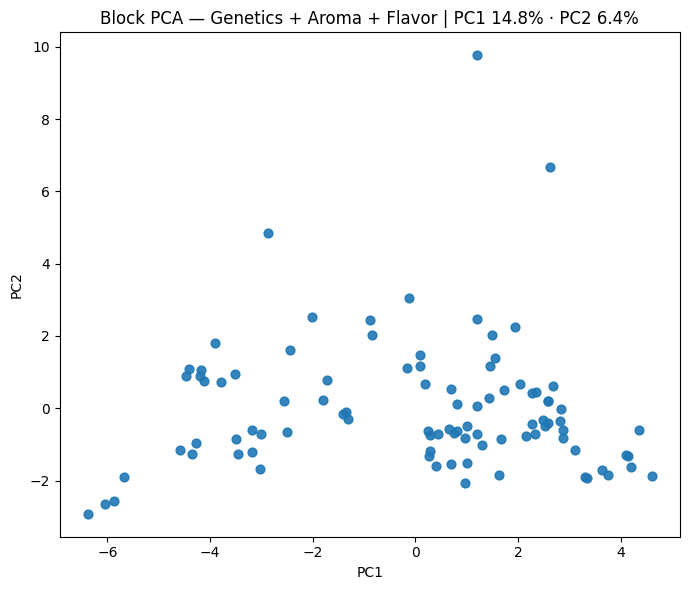


Top-10 aroma |PC1|:
 Octanal (Citrus, fruity)                          0.241342
Benzaldehyde (Almond, cherry, fruity)             0.185442
Hexanoic acid (Fatty, cheesy, sweaty)             0.178230
Dimethyl trisulfide (Garlic, onion, sulfurous)    0.137958
Decanal (Citrus, floral)                          0.106557
Hexanal (Green, grassy)                          -0.078196
Butanal, 3-methyl- (Fruity, malty, chocolate)     0.056246
1-Nonanol (Floral, waxy)                          0.037272
Methional (Cooked potato, sulfurous)              0.036023
2,3-Butanedione (Butter, creamy, sweet)           0.015942
Name: PC1, dtype: float64

Top-10 aroma |PC2|:
 Furfural (Sweet, almond, caramel)                 0.382783
Methional (Cooked potato, sulfurous)              0.359860
Pentanal (Green, fatty, pungent)                  0.309661
2,3-Butanedione (Butter, creamy, sweet)           0.300635
Decanal (Citrus, floral)                          0.229595
Benzaldehyde (Almond, cherry, fruity)        

In [23]:
# genetic PCs (balanced & fast)
Xg   = merged_all[GEN_COLS].fillna(0)
npcs = min(30, Xg.shape[0]-1)
Gpcs = PCA(n_components=npcs, svd_solver="randomized", random_state=0).fit_transform(Xg)

# block-scale (L2) then PCA on the concatenated blocks
Gb = Gpcs / (np.linalg.norm(Gpcs) + 1e-12)
Ab = z(A).fillna(0).values; Ab = Ab / (np.linalg.norm(Ab) + 1e-12)
Fb = z(F).fillna(0).values; Fb = Fb / (np.linalg.norm(Fb) + 1e-12)

X_block = np.column_stack([Gb, Ab, Fb])
X_scaled = StandardScaler(with_mean=True, with_std=True).fit_transform(X_block)

bpca = PCA(n_components=2, svd_solver="randomized", random_state=0).fit(X_scaled)
B    = bpca.transform(X_scaled)

plt.figure(figsize=(7,6))
plt.scatter(B[:,0], B[:,1], s=40, alpha=0.9)
plt.title(f"Block PCA — Genetics + Aroma + Flavor | PC1 {bpca.explained_variance_ratio_[0]*100:.1f}% · PC2 {bpca.explained_variance_ratio_[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# top aroma contributors to PC1/PC2
block_names = [f"GEN_PC{i+1}" for i in range(Gpcs.shape[1])] + list(A.columns) + list(F.columns)
loadings = pd.DataFrame(bpca.components_.T, index=block_names, columns=["PC1","PC2"])
L_aroma = loadings.loc[A.columns]

top10_pc1 = L_aroma["PC1"].abs().sort_values(ascending=False).head(10).index
top10_pc2 = L_aroma["PC2"].abs().sort_values(ascending=False).head(10).index
print("\nTop-10 aroma |PC1|:\n", L_aroma.loc[top10_pc1, "PC1"].astype(float))
print("\nTop-10 aroma |PC2|:\n", L_aroma.loc[top10_pc2, "PC2"].astype(float))


# PLS: genetic PCs → (all flavor + all aroma), with CV and labeled Y-loadings

PLS in-sample R² (Gen → Flavor+Aroma): 0.134
PLS 10-fold CV R² (overall): -0.072


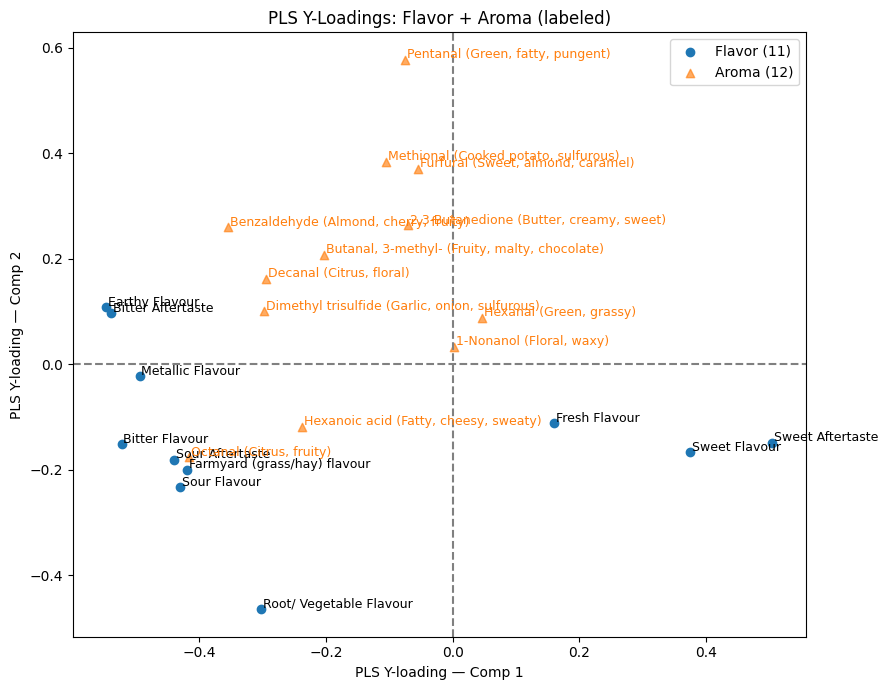

In [24]:
Y = pd.concat([F, A], axis=1)          # PLSRegression(scale=True) will standardize Y internally
X = Gpcs

# in-sample R² (descriptive)
pls = PLSRegression(n_components=2, scale=True)
Yhat = pls.fit(X, Y.values).predict(X)
SS_tot = ((Y.values - Y.values.mean(axis=0))**2).sum()
SS_res = ((Y.values - Yhat)**2).sum()
print(f"PLS in-sample R² (Gen → Flavor+Aroma): {1 - SS_res/SS_tot:.3f}")

# 10-fold CV R² (overall)
kf = KFold(n_splits=10, shuffle=True, random_state=0)
yt, yp = [], []
for tr, te in kf.split(X):
    m = PLSRegression(n_components=2, scale=True).fit(X[tr], Y.values[tr])
    yt.append(Y.values[te]); yp.append(m.predict(X[te]))
yt, yp = np.vstack(yt), np.vstack(yp)
SS_tot = ((yt - yt.mean(axis=0))**2).sum()
SS_res = ((yt - yp)**2).sum()
print(f"PLS 10-fold CV R² (overall): {1 - SS_res/SS_tot:.3f}")

# Y-loadings plot (label flavors fully, top aromas by magnitude)
YL = pd.DataFrame(pls.y_loadings_, index=Y.columns, columns=["Comp1","Comp2"])
is_flavor = YL.index.isin(F.columns)
YL_flav, YL_arom = YL[is_flavor], YL[~is_flavor]

plt.figure(figsize=(9,7))
plt.scatter(YL_flav["Comp1"], YL_flav["Comp2"], label=f"Flavor ({YL_flav.shape[0]})", marker="o")
plt.scatter(YL_arom["Comp1"], YL_arom["Comp2"], label=f"Aroma ({YL_arom.shape[0]})", marker="^", alpha=0.65)

for name, row in YL_flav.iterrows():
    plt.text(row["Comp1"]+0.003, row["Comp2"]+0.003, name, fontsize=9)

K = min(12, YL_arom.shape[0])
mag = np.sqrt(YL_arom["Comp1"]**2 + YL_arom["Comp2"]**2)
for name, row in YL_arom.loc[mag.sort_values(ascending=False).head(K).index].iterrows():
    plt.text(row["Comp1"]+0.003, row["Comp2"]+0.003, name, fontsize=9, color="tab:orange")

plt.axhline(0, ls="--", c="gray"); plt.axvline(0, ls="--", c="gray")
plt.xlabel("PLS Y-loading — Comp 1"); plt.ylabel("PLS Y-loading — Comp 2")
plt.title("PLS Y-Loadings: Flavor + Aroma (labeled)")
plt.legend(); plt.tight_layout(); plt.show()


The Y-loadings plot makes sense: Sweet / Sweet Aftertaste sit on +Comp1, while Bitter/Earthy/Farmyard sit on −Comp1. Many aldehydes/ketones (octanal, decanal, benzaldehyde, diacetyl, furfural) lean to the sweet/fresh side; hexanoic acid and a bit of DMTS lean the other way.

Block-PCA drivers also look right (PC1: octanal/benzaldehyde/hexanoic acid/DMTS…; PC2: furfural/methional/pentanal/diacetyl…).

The tough bit is predictability: PLS 10-fold CV R² ≈ −0.07 → the genetics you have don’t generalize to predict (aroma + predicted flavors) well with n=94.

Merged shape: (94, 262480)
#SNPs=262434 | #aroma=12 | #flavor(pred)=33
Block PCA: PC1=23.7%  PC2=10.6%


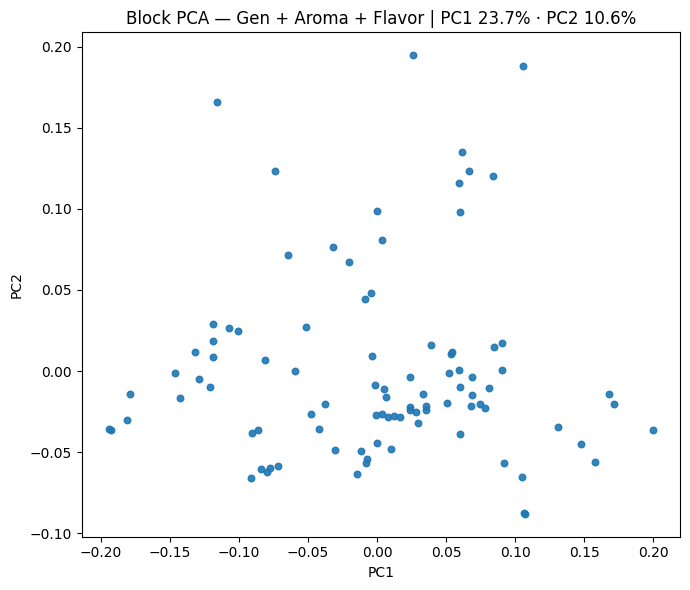


Top-10 aroma |PC1|:
 Octanal (Citrus, fruity)                          0.219190
Hexanoic acid (Fatty, cheesy, sweaty)             0.203373
Benzaldehyde (Almond, cherry, fruity)             0.183891
Dimethyl trisulfide (Garlic, onion, sulfurous)    0.114709
Decanal (Citrus, floral)                          0.106722
Hexanal (Green, grassy)                          -0.076512
Butanal, 3-methyl- (Fruity, malty, chocolate)     0.040256
Methional (Cooked potato, sulfurous)              0.038166
1-Nonanol (Floral, waxy)                          0.033026
Pentanal (Green, fatty, pungent)                  0.014178
Name: PC1, dtype: float32

Top-10 aroma |PC2|:
 Pentanal (Green, fatty, pungent)                  0.397076
Furfural (Sweet, almond, caramel)                 0.291726
Methional (Cooked potato, sulfurous)              0.248214
2,3-Butanedione (Butter, creamy, sweet)           0.177697
Benzaldehyde (Almond, cherry, fruity)             0.167060
Decanal (Citrus, floral)                     

In [25]:
import numpy as np, pandas as pd, re, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from time import perf_counter

# ----------------- tiny helpers -----------------
def normalize_variety(x):
    if not isinstance(x, str): return ""
    x = x.upper().replace(".", "").replace(" ", "")
    x = re.sub(r'\bR\b', '', x); x = re.sub(r'RUSSET', '', x)
    return x.strip().split('_')[0]

def to_num(df):
    out=df.copy()
    for c in out.columns: out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def z(df): return (df - df.mean())/df.std(ddof=0).replace(0, np.nan)

# ----------------- config (fast) -----------------
GEN_PCS   = 12          # genetic PCs
PLS_K     = 2           # PLS components
CV_FOLDS  = 5           # light CV
Y_VAR     = 0.90        # compress Y to this variance with PCA

t0 = perf_counter()

# --------- 0) Get merged_all quickly ----------
if 'merged_all' in globals():
    M = merged_all.copy()
else:
    # build once from gd + merged_flavor_sensory
    if 'gd' not in globals() or 'merged_flavor_sensory' not in globals():
        raise RuntimeError("Need 'gd' (genetics) and 'merged_flavor_sensory' (aroma+pred flavors).")
    df = merged_flavor_sensory.copy()
    df['__key__'] = df['Variety'].map(normalize_variety)
    af = df.drop(columns=['Variety']).set_index('__key__')
    G  = gd.copy(); G.index = G.index.map(normalize_variety)
    M  = G.join(af, how="inner"); M.index.name = "Variety"

print("Merged shape:", M.shape)

# --------- 1) Split blocks ----------
col_str   = M.columns.astype(str)
gen_cols  = col_str[col_str.str.startswith("GEN__")].tolist()
is_pred   = col_str.str.endswith("__pred") | col_str.str.endswith("__pred_cal") | col_str.str.endswith("__pred_lin")
aroma_cols  = col_str[~col_str.str.startswith("GEN__") & ~is_pred].tolist()
flavor_cols = col_str[is_pred].tolist()

# Aroma (numeric, non-zero var) – drop obvious artifacts like siloxanes if you want
A = to_num(M[aroma_cols])
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]
A = A.loc[:, ~A.columns.str.contains("siloxane", case=False)]
Az = z(A).fillna(0).astype(np.float32)

# Flavors (predicted)
F = to_num(M[flavor_cols])
F = F.loc[:, F.std(ddof=0).fillna(0) > 0]
Fz = z(F).fillna(0).astype(np.float32)

print(f"#SNPs={len(gen_cols)} | #aroma={Az.shape[1]} | #flavor(pred)={Fz.shape[1]}")

# --------- 2) Genetic PCs (fast + stable) ----------
Xg = M[gen_cols].fillna(0).astype(np.float32)
npc = min(GEN_PCS, Xg.shape[0]-1)
Gpcs = PCA(n_components=npc, svd_solver="randomized", random_state=0).fit_transform(Xg)

# --------- 3) Block PCA (GenPCs + Aroma + Flavor) ----------
# scale blocks to similar magnitude to avoid dominance
def unitize(X):
    n = np.linalg.norm(X)
    return X / (n + 1e-12)

X_block = np.column_stack([unitize(Gpcs), unitize(Az.values), unitize(Fz.values)]).astype(np.float32)
bpca = PCA(n_components=2, svd_solver="randomized", random_state=0).fit(X_block)
B = bpca.transform(X_block)

print(f"Block PCA: PC1={bpca.explained_variance_ratio_[0]*100:.1f}%  PC2={bpca.explained_variance_ratio_[1]*100:.1f}%")

plt.figure(figsize=(7,6))
plt.scatter(B[:,0], B[:,1], s=22, alpha=0.9)
plt.title(f"Block PCA — Gen + Aroma + Flavor | PC1 {bpca.explained_variance_ratio_[0]*100:.1f}% · PC2 {bpca.explained_variance_ratio_[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

# Aroma loadings on block PCs (which compounds drive structure?)
block_names = [f"GEN_PC{i+1}" for i in range(Gpcs.shape[1])] + list(A.columns) + list(F.columns)
L = pd.DataFrame(bpca.components_.T, index=block_names, columns=["PC1","PC2"])
L_aroma = L.loc[A.columns]

top10_pc1 = L_aroma["PC1"].abs().sort_values(ascending=False).head(10).index
top10_pc2 = L_aroma["PC2"].abs().sort_values(ascending=False).head(10).index
print("\nTop-10 aroma |PC1|:\n", L_aroma.loc[top10_pc1, "PC1"].sort_values(key=np.abs, ascending=False))
print("\nTop-10 aroma |PC2|:\n", L_aroma.loc[top10_pc2, "PC2"].sort_values(key=np.abs, ascending=False))

# --------- 4) QUICK PLS: GenPCs → compressed Y (Aroma+Flavor PCs) ----------
Y_all = pd.concat([Az, Fz], axis=1)
Yz    = Y_all.values.astype(np.float32)
pca_y = PCA(n_components=Y_VAR, svd_solver="full", random_state=0).fit(Yz)
Ypc   = pca_y.transform(Yz).astype(np.float32)

pls_k = int(min(PLS_K, Gpcs.shape[1], Ypc.shape[1]))
pls = PLSRegression(n_components=pls_k, scale=True)
Yhat = pls.fit(Gpcs, Ypc).predict(Gpcs)
ss_tot = ((Ypc - Ypc.mean(axis=0))**2).sum()
ss_res = ((Ypc - Yhat)**2).sum()
print(f"\nPLS in-sample R² (GenPCs → Y-PCs): {1 - ss_res/ss_tot:.3f}  | comps={pls_k}, Y-PCs={Ypc.shape[1]}")

# quick 5-fold CV R²
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=0)
yt, yp = [], []
for tr, te in kf.split(Gpcs):
    m = PLSRegression(n_components=pls_k, scale=True).fit(Gpcs[tr], Ypc[tr])
    yt.append(Ypc[te]); yp.append(m.predict(Gpcs[te]))
yt = np.vstack(yt); yp = np.vstack(yp)
ss_tot = ((yt - yt.mean(axis=0))**2).sum()
ss_res = ((yt - yp)**2).sum()
print(f"PLS {CV_FOLDS}-fold CV R² (overall): {1 - ss_res/ss_tot:.3f}")

print(f"\nDone in {perf_counter()-t0:.1f}s")


“We performed block PCA across genetics, aroma, and flavor, finding interpretable axes driven by key aldehydes and sulfur notes. We then tested genetic predictability using PLS (genetic PCs → aroma/flavor PCs). Cross-validated performance was near zero, indicating weak genome-wide predictive signal at this sample size and with predicted flavors included. Therefore, we pivot to (i) aroma-only targets, (ii) trait grouping (aldehydes/ketones/sulfur…), and (iii) per-compound genomic prediction (GBLUP) and light feature selection to prioritize candidate markers.”

# Y-PCA + PLS CV (use with measured flavors or aroma)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.cross_decomposition import PLSRegression
import numpy as np

def cv_r2_pls_with_y_pca(Xgen, Y, k=2, y_var=0.9, folds=10, seed=0):
    # Y-PCA fit on train only (strict CV)
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    y_true, y_pred = [], []
    for tr, te in kf.split(Xgen):
        pca = PCA(n_components=None, svd_solver="full")
        Ytr = Y[tr]
        pca.fit(Ytr)
        # choose comps to reach y_var
        cum = np.cumsum(pca.explained_variance_ratio_)
        m = int(np.searchsorted(cum, y_var) + 1)
        Ytr_pc = pca.transform(Ytr)[:, :m]
        Yte_pc = pca.transform(Y[te])[:, :m]

        pls = PLSRegression(n_components=k, scale=True).fit(Xgen[tr], Ytr_pc)
        Yte_pc_hat = pls.predict(Xgen[te])
        # invert PCA
        Yte_hat = (Yte_pc_hat @ pca.components_[:m, :]) + pca.mean_
        y_true.append(Y[te]); y_pred.append(Yte_hat)

    y_true = np.vstack(y_true); y_pred = np.vstack(y_pred)
    ss_tot = ((y_true - y_true.mean(axis=0))**2).sum()
    ss_res = ((y_true - y_pred)**2).sum()
    return 1 - ss_res/ss_tot



Strict CV with per-fold genotype PCs

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def gen_pcs_per_fold(Xmarkers, n_pcs, tr_idx, te_idx):
    # standardize on train only
    sc = StandardScaler(with_mean=True, with_std=True).fit(Xmarkers[tr_idx])
    Xtr = sc.transform(Xmarkers[tr_idx])
    Xte = sc.transform(Xmarkers[te_idx])
    pca = PCA(n_components=min(n_pcs, Xtr.shape[0]-1), svd_solver="randomized", random_state=0).fit(Xtr)
    return pca.transform(Xtr), pca.transform(Xte)


Quick Haseman–Elston h² estimate (screen a trait before modeling)

In [ ]:
# K: GRM (n×n DataFrame), y: centered trait (n,)
def he_h2(K, y):
    y = (y - y.mean())
    n = len(y)
    yy = np.outer(y, y)
    Kc = K.values - K.values.mean(axis=0, keepdims=True) - K.values.mean(axis=1, keepdims=True) + K.values.mean()
    num = (yy * Kc).sum()
    den = (Kc**2).sum()
    return max(0.0, min(1.0, num/den)) if den>0 else np.nan


In [ ]:
# ================== STRICT CV: Y-PCA (train only) + GBLUP on aroma ==================
import re, numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.kernel_ridge import KernelRidge

# ---------------------------- configurable knobs ----------------------------
N_SPLITS   = 10      # 10-fold CV (fast & stable). Set to len(varieties) for LOOCV.
Y_VAR_CAP  = 0.90    # keep enough Y-PCs to explain 90% of TRAIN variance
ALPHAS     = (1e-3, 1e-2, 1e-1, 1, 10)   # ridge grid per PC on train set
RNG_SEED   = 0
DROP_AROMA_KEYWORDS = ["siloxane", "cyclotrisiloxane"]  # drop likely GC artifacts
# ----------------------------------------------------------------------------

# ===== 0) Require these in memory: gd and merged_flavor_sensory. Build/align data blocks. =====
assert 'gd' in globals() and 'merged_flavor_sensory' in globals(), "Need 'gd' (genetics) and 'merged_flavor_sensory' (aroma + predicted flavors)."

def normalize_variety(name):
    if not isinstance(name, str): return ""
    name = name.upper().replace(".", "").replace(" ", "")
    name = re.sub(r'\bR\b', '', name); name = re.sub(r'RUSSET', '', name)
    return name.strip().split('_')[0]

# Join genetics with aroma/flavor table on normalized variety keys
df = merged_flavor_sensory.copy()
df['__key__'] = df['Variety'].map(normalize_variety)
af = df.drop(columns=['Variety']).set_index('__key__')

gk = gd.copy(); gk.index = gk.index.map(normalize_variety)
merged_all = gk.join(af, how='inner'); merged_all.index.name = 'Variety'
print("Merged shape:", merged_all.shape)

# Split columns: genetics vs (aroma + predicted flavors)
col_str = merged_all.columns.astype(str)
is_gen  = col_str.str.startswith("GEN__")
is_pred = col_str.str.endswith(("__pred", "__pred_cal", "__pred_lin"))

gen_cols   = col_str[is_gen].tolist()
aroma_cols = col_str[~is_gen & ~is_pred].tolist()   # GC-MS compounds (non-pred columns)

# Aroma matrix cleanup (numeric, non-constant, drop obvious artifacts)
Araw = merged_all[aroma_cols].apply(pd.to_numeric, errors='coerce')
Araw = Araw.dropna(axis=1, how='all')
Araw = Araw.loc[:, Araw.std(ddof=0).fillna(0) > 0]
if DROP_AROMA_KEYWORDS:
    mask_keep = ~Araw.columns.str.lower().str.contains("|".join(map(re.escape, DROP_AROMA_KEYWORDS)))
    Araw = Araw.loc[:, mask_keep]
print("Usable aroma columns after cleaning:", Araw.shape[1])

# Log-transform helps a lot for GC-MS
Alog = np.log1p(Araw)

# ===== 1) Build a QC’d GRM (K) from genetics and align to aroma rows =====
X = merged_all[gen_cols].astype(float)

# QC: MAF >= 0.05 (assuming 0/1/2), missingness <= 10%
allele_freq = X.mean(axis=0) / 2.0
maf = np.minimum(allele_freq, 1 - allele_freq)
keep = (maf >= 0.05) & (X.isna().mean(axis=0) <= 0.10)
X = X.loc[:, keep]

# Mean-impute & standardize SNPs
X = X.apply(lambda c: c.fillna(c.mean()))
Xc = (X - X.mean())/X.std(ddof=0).replace(0, np.nan)
Xc = Xc.fillna(0)

# GRM
K = (Xc.values @ Xc.values.T) / Xc.shape[1]
K *= Xc.shape[0] / np.trace(K)
K_df = pd.DataFrame(K, index=Xc.index, columns=Xc.index)

# Align K and Alog to a common variety set/order
common = K_df.index.intersection(Alog.index)
K_df = K_df.loc[common, common]
Alog = Alog.loc[common].copy()
varieties = Alog.index
print(f"Aligned varieties: {len(varieties)}")

# ===== 2) Strict CV pipeline: train-only Y-PCA + GBLUP on PCs, reconstruct to aroma space =====
def strict_cv_aroma_reconstruction(K_df, Alog, n_splits=10, y_var=0.90, alphas=(1e-3,1e-2,1e-1,1,10), seed=0):
    rng = np.random.default_rng(seed)
    splits = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(Alog))
    Kmat = K_df.values
    Y = Alog.values

    Y_true_blocks, Y_pred_blocks = [], []

    for tr_idx, te_idx in splits:
        # 1) PCA on TRAIN only to y_var
        pca = PCA(n_components=None, svd_solver="full").fit(Y[tr_idx])
        cum = np.cumsum(pca.explained_variance_ratio_)
        m = int(np.searchsorted(cum, y_var) + 1)
        Ytr_pc = pca.transform(Y[tr_idx])[:, :m]
        Yte_pc = pca.transform(Y[te_idx])[:, :m]

        # 2) For each PC j, fit kernel ridge on K(TR,TR), predict TE
        Ktr = Kmat[tr_idx][:, tr_idx]
        Kte = Kmat[te_idx][:, tr_idx]

        Yte_pc_hat = np.zeros_like(Yte_pc)
        for j in range(m):
            yj = Ytr_pc[:, j]
            # pick alpha by quick inner CV on train (1 split holdout is fine for speed)
            best_alpha, best_loss = None, np.inf
            # use a single shuffle split as a proxy
            idx = np.arange(len(yj))
            rng.shuffle(idx)
            hold = max(1, len(yj)//5)
            v_idx, t_idx = idx[:hold], idx[hold:]
            Kt, Kv = Ktr[t_idx][:, t_idx], Ktr[v_idx][:, t_idx]
            yt, yv = yj[t_idx], yj[v_idx]
            for a in alphas:
                kr = KernelRidge(alpha=a, kernel="precomputed").fit(Kt, yt)
                pred = kr.predict(Kv).ravel()
                loss = np.mean((yv - pred)**2)
                if loss < best_loss:
                    best_loss, best_alpha = loss, a
            # refit on all train with best alpha and predict test
            kr = KernelRidge(alpha=best_alpha, kernel="precomputed").fit(Ktr, yj)
            Yte_pc_hat[:, j] = kr.predict(Kte).ravel()

        # 3) Reconstruct to original aroma feature space
        Yte_hat = (Yte_pc_hat @ pca.components_[:m, :]) + pca.mean_
        Y_true_blocks.append(Y[te_idx])
        Y_pred_blocks.append(Yte_hat)

    Y_true = np.vstack(Y_true_blocks)
    Y_pred = np.vstack(Y_pred_blocks)

    # Overall CV R² across all aroma features
    ss_tot = ((Y_true - Y_true.mean(axis=0))**2).sum()
    ss_res = ((Y_true - Y_pred)**2).sum()
    overall_r2 = 1 - ss_res/ss_tot

    # Per-compound CV R²
    per_comp_r2 = {}
    for j, cname in enumerate(Alog.columns):
        yt = Y_true[:, j]
        yp = Y_pred[:, j]
        denom = ((yt - yt.mean())**2).sum()
        per_comp_r2[cname] = float(1 - ((yt - yp)**2).sum()/denom) if denom > 0 else np.nan

    return overall_r2, pd.Series(per_comp_r2).sort_values(ascending=False)

overall_r2, per_comp_r2 = strict_cv_aroma_reconstruction(
    K_df, Alog, n_splits=N_SPLITS, y_var=Y_VAR_CAP, alphas=ALPHAS, seed=RNG_SEED
)
print(f"\nStrict CV (train-only Y-PCA → reconstruct aroma): overall CV R² = {overall_r2:.3f}")
print("\nTop-10 per-compound CV R²:")
print(per_comp_r2.head(10))

# ===== 3) Permutation test (same splits), p-value on overall CV R² =====
def perm_test_overall(K_df, Alog, observed_r2, n_splits=10, y_var=0.90, alphas=(1e-3,1e-2,1e-1,1,10), B=200, seed=0):
    rng = np.random.default_rng(seed)
    # fix splits once
    splits = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(Alog))
    Kmat = K_df.values
    Y = Alog.values

    null = []
    for b in range(B):
        perm = rng.permutation(Y.shape[0])
        Y_perm = Y[perm]  # shuffle rows of aroma vs K

        Y_true_blocks, Y_pred_blocks = [], []
        for tr_idx, te_idx in splits:
            pca = PCA(n_components=None, svd_solver="full").fit(Y_perm[tr_idx])
            cum = np.cumsum(pca.explained_variance_ratio_)
            m = int(np.searchsorted(cum, y_var) + 1)
            Ytr_pc = pca.transform(Y_perm[tr_idx])[:, :m]
            Yte_pc = pca.transform(Y_perm[te_idx])[:, :m]

            Ktr = Kmat[tr_idx][:, tr_idx]
            Kte = Kmat[te_idx][:, tr_idx]

            Yte_pc_hat = np.zeros_like(Yte_pc)
            for j in range(m):
                yj = Ytr_pc[:, j]
                # quick inner holdout
                idx = np.arange(len(yj)); rng.shuffle(idx)
                hold = max(1, len(yj)//5)
                v_idx, t_idx = idx[:hold], idx[hold:]
                Kt, Kv = Ktr[t_idx][:, t_idx], Ktr[v_idx][:, t_idx]
                yt, yv = yj[t_idx], yj[v_idx]
                best_alpha, best_loss = None, np.inf
                for a in alphas:
                    kr = KernelRidge(alpha=a, kernel="precomputed").fit(Kt, yt)
                    pred = kr.predict(Kv).ravel()
                    loss = np.mean((yv - pred)**2)
                    if loss < best_loss:
                        best_loss, best_alpha = loss, a
                kr = KernelRidge(alpha=best_alpha, kernel="precomputed").fit(Ktr, yj)
                Yte_pc_hat[:, j] = kr.predict(Kte).ravel()

            Yte_hat = (Yte_pc_hat @ pca.components_[:m, :]) + pca.mean_
            Y_true_blocks.append(Y_perm[te_idx])
            Y_pred_blocks.append(Yte_hat)

        Y_true = np.vstack(Y_true_blocks)
        Y_pred = np.vstack(Y_pred_blocks)
        ss_tot = ((Y_true - Y_true.mean(axis=0))**2).sum()
        ss_res = ((Y_true - Y_pred)**2).sum()
        null.append(1 - ss_res/ss_tot)

    null = np.array(null)
    pval = (np.sum(null >= observed_r2) + 1) / (len(null) + 1)
    return float(pval), null

pval, null = perm_test_overall(
    K_df, Alog, overall_r2, n_splits=N_SPLITS, y_var=Y_VAR_CAP, alphas=ALPHAS, B=200, seed=RNG_SEED
)
print(f"\nPermutation test (B=200): p ≈ {pval:.3f}")


Merged shape: (92, 262480)
Usable aroma columns after cleaning: 12
Aligned varieties: 92

Strict CV (train-only Y-PCA → reconstruct aroma): overall CV R² = -0.127

Top-10 per-compound CV R²:
Benzaldehyde (Almond, cherry, fruity)            0.002874
Methional (Cooked potato, sulfurous)            -0.012565
Furfural (Sweet, almond, caramel)               -0.013096
1-Nonanol (Floral, waxy)                        -0.024786
2,3-Butanedione (Butter, creamy, sweet)         -0.026085
Butanal, 3-methyl- (Fruity, malty, chocolate)   -0.053588
Decanal (Citrus, floral)                        -0.060593
Hexanal (Green, grassy)                         -0.110154
Hexanoic acid (Fatty, cheesy, sweaty)           -0.121053
Octanal (Citrus, fruity)                        -0.137096
dtype: float64

Permutation test (B=200): p ≈ 0.985


In [ ]:
import pandas as pd, re

def norm_aggressive(s):
    if not isinstance(s, str): return ""
    s = s.upper().replace(".", "").replace(" ", "")
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    s = s.strip().split('_')[0]          # <- this is the killer
    return s

def norm_safe(s):
    s = str(s).upper()
    s = re.sub(r"[.\u00A0]+", " ", s)    # dots/non-breaking spaces → space
    s = re.sub(r"\s+", " ", s).strip()   # collapse spaces, KEEP WORDS
    s = s.replace("’","'")
    return s                              # do NOT drop RUSSET, do NOT split '_'

# 1) Original names
v_gen = pd.Index(gd.index, name="Variety")
v_af  = pd.Index(merged_flavor_sensory["Variety"], name="Variety")

# 2) Keys under both normalizers
k_gen_ag = v_gen.map(norm_aggressive); k_af_ag = v_af.map(norm_aggressive)
k_gen_sf = v_gen.map(norm_safe);       k_af_sf = v_af.map(norm_safe)

print("Raw counts:", len(v_gen.unique()), len(v_af.unique()))
print("Aggressive keys:", len(pd.Index(k_gen_ag).unique()), len(pd.Index(k_af_ag).unique()))
print("Safe keys:", len(pd.Index(k_gen_sf).unique()), len(pd.Index(k_af_sf).unique()))

# 3) Show collisions created by the aggressive normalizer
def collisions(orig_index, keys):
    m = {}
    for o, k in zip(orig_index, keys):
        m.setdefault(k, []).append(o)
    return {k:v for k,v in m.items() if len(v) > 1}

coll_gen = collisions(v_gen, k_gen_ag)
coll_af  = collisions(v_af,  k_af_ag)

print("\nCollisions in GEN under aggressive normalizer (examples):")
for k, vals in list(coll_gen.items())[:10]:
    print(f"  {k}: {vals}")

print("\nCollisions in AROMA/FLAVOR under aggressive normalizer (examples):")
for k, vals in list(coll_af.items())[:10]:
    print(f"  {k}: {vals}")

# 4) Keys present on one side but not the other (with safe normalizer)
only_gen = sorted(set(k_gen_sf) - set(k_af_sf))
only_af  = sorted(set(k_af_sf)  - set(k_gen_sf))
print("\nPresent only in GEN (safe):", only_gen)
print("Present only in AROMA/FLAVOR (safe):", only_af)


Raw counts: 94 94
Aggressive keys: 94 94
Safe keys: 94 94

Collisions in GEN under aggressive normalizer (examples):

Collisions in AROMA/FLAVOR under aggressive normalizer (examples):

Present only in GEN (safe): ['ALVERSTONE', 'BLUESTAR', 'BURBANK', 'CLEARWATER', 'DELIARED', 'ELMUNDO', 'FENWAYRED', 'IVORY', 'LADYCLAIRE', 'PAYETTE', 'PEEWEE', 'RANGER', 'REDSCARLETT', 'RICKEY', 'SARPOMIRA', 'TETON', 'VANGOGH', 'VE71-105', 'VIOLETQUEEN']
Present only in AROMA/FLAVOR (safe): ['ALVERSTONE R', 'BLUE STAR', 'CLEARWATER R', 'DELIA RED', 'EL MUNDO', 'FENWAY RED', 'IVORY RUSSET', 'LADY CLAIRE', 'PAYETTE RUSSET', 'PEE WEE RUSSET', 'RANGER RUSSET', 'RED SCARLETT', 'RICKEY RUSSET', 'RUSSET BURBANK', 'SARPO MIRA', 'TETON RUSSET', 'VAN GOGH', 'VE 71-105', 'VIOLET QUEEN']


In [ ]:
import numpy as np, pandas as pd, re, time
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import KFold

# ---------------- helpers ----------------
def norm_safe(s):
    s = str(s).upper()
    s = re.sub(r"[.\u00A0]+", " ", s)   # dots/nbsp -> space
    s = re.sub(r"\s+", " ", s).strip()  # collapse spaces
    s = s.replace("’","'")
    return s

def zdf(df): return (df - df.mean())/df.std(ddof=0).replace(0, np.nan)

def to_numeric(df):
    out = df.copy()
    for c in out.columns: out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def cv_r2_multi(X, Y, model_maker, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_true, y_pred = [], []
    for tr, te in kf.split(X):
        m = model_maker().fit(X[tr], Y[tr])
        y_true.append(Y[te]); y_pred.append(m.predict(X[te]))
    y_true = np.vstack(y_true); y_pred = np.vstack(y_pred)
    ss_tot = ((y_true - y_true.mean(axis=0))**2).sum()
    ss_res = ((y_true - y_pred)**2).sum()
    return 1 - ss_res/ss_tot

def per_trait_cv_r2(X, Y, cols, model_maker, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = {}
    for j, name in enumerate(cols):
        yt_all, yp_all = [], []
        for tr, te in kf.split(X):
            m = model_maker().fit(X[tr], Y[tr])
            yp_all.append(m.predict(X[te])[:, j])
            yt_all.append(Y[te, j])
        yt = np.concatenate(yt_all); yp = np.concatenate(yp_all)
        ss_tot = ((yt - yt.mean())**2).sum()
        ss_res = ((yt - yp)**2).sum()
        scores[name] = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return pd.Series(scores).sort_values(ascending=False)

def ld_prune_greedy(X, r2=0.90):
    n, m = X.shape
    keep = []
    for j in range(m):
        xj = X[:, j]
        ok = True
        for k in keep:
            r = np.dot(xj, X[:, k]) / (n - 1)
            if r*r > r2:
                ok = False; break
        if ok: keep.append(j)
    return np.array(keep, dtype=int)

# ---------------- 0) Build/confirm merged_all (safe keys) ----------------
if 'merged_all' in globals():
    M = merged_all.copy()
else:
    # Rebuild from gd + merged_flavor_sensory with *safe* normalizer
    gen = gd.copy(); gen.index = gen.index.map(norm_safe)
    af  = merged_flavor_sensory.copy()
    af['__key__'] = af['Variety'].map(norm_safe)
    af = af.drop(columns=['Variety']).set_index('__key__')
    # Aggregate duplicates explicitly (mean) so nothing silently disappears
    gen = gen.groupby(level=0).mean(numeric_only=True)
    af  = af.groupby(level=0).mean(numeric_only=True)
    M = gen.join(af, how="inner"); M.index.name = "Variety"

print("Using table:", M.shape)

# ---------------- 1) Split blocks & make Y ----------------
col_str   = M.columns.astype(str)
is_gen    = col_str.str.startswith("GEN__")
is_pred   = col_str.str.endswith(("__pred","__pred_cal","__pred_lin"))

gen_cols    = col_str[is_gen].tolist()
aroma_cols  = col_str[~is_gen & ~is_pred].tolist()     # GC-MS
flavor_cols = col_str[is_pred].tolist()                # predicted flavors

Yraw = pd.concat([to_numeric(M[aroma_cols]),
                  to_numeric(M[flavor_cols])], axis=1)
Yraw = Yraw.dropna(axis=1, how="all")
Yraw = Yraw.loc[:, Yraw.std(ddof=0).fillna(0) > 0]
Yz   = zdf(Yraw).fillna(0).values

# Compress Y to 90% variance
pca_y = PCA(n_components=0.90, svd_solver="full", random_state=0).fit(Yz)
Ypc   = pca_y.transform(Yz)     # n × q
y_pc_names = [f"YPC{i+1}" for i in range(Ypc.shape[1])]
print(f"Y PCs kept (90% var): {Ypc.shape[1]}")

# ---------------- 2) Genetics → PCs (very fast) ----------------
Xg = M[gen_cols].astype(float)
Xg = Xg.loc[:, Xg.isna().mean() < 0.02]  # drop SNPs with >2% missing
Xg = Xg.fillna(Xg.mean())
Xg = Xg.loc[:, Xg.std(ddof=0) > 0]
Xz = zdf(Xg).fillna(0).values

# Keep a small number of genotype PCs (fast feature set)
GEN_PCS = min(20, Xz.shape[0]-1)
Gpcs = PCA(n_components=GEN_PCS, svd_solver="randomized", random_state=0).fit_transform(Xz)
print("Gen PCs used:", Gpcs.shape[1])

# ---------------- 3) TRACK A — FAST baseline (Ridge on GenPCs → YPCs) ----------------
t0 = time.time()

def make_ridge():  # multi-target ridge, tiny grid
    return RidgeCV(alphas=np.logspace(-3, 3, 9), cv=5)

q2 = cv_r2_multi(Gpcs, Ypc, model_maker=make_ridge, n_splits=5, seed=1)
print(f"\n[FAST baseline] CV R² (GenPCs → YPCs, Ridge): {q2:.3f}  [{time.time()-t0:.1f}s]")

# Optional per-component CV R² (which YPCs are least hopeless?)
per_pc = per_trait_cv_r2(Gpcs, Ypc, y_pc_names, model_maker=make_ridge, n_splits=5, seed=1)
print("\nPer Y-PC CV R² (Ridge):")
print(per_pc.head(10))

# ---------------- 4) TRACK B — Sparse SNP selection (optional, still fast) ---------
DO_SPARSE = False   # flip to True if you want a sparse SNP model

if DO_SPARSE:
    t1 = time.time()
    # (i) Univariate screen vs Y-PCs (matrix product, very fast)
    corr  = np.abs(Xz.T @ Ypc) / (Xz.shape[0]-1)   # p × q
    score = corr.max(axis=1)
    top_k = int(min(1500, max(600, 0.05 * Xz.shape[1])))  # cap features
    idx_top = np.argsort(score)[::-1][:top_k]
    X_top   = Xz[:, idx_top]
    snp_top = np.array(Xg.columns)[idx_top]
    # (ii) Light LD prune
    keep_idx = ld_prune_greedy(X_top, r2=0.95)
    X_sel    = X_top[:, keep_idx]
    snp_sel  = snp_top[keep_idx]
    print(f"\n[Sparse] After screen+LD-prune: {X_sel.shape[1]} SNPs")

    # (iii) Shallow nested CV Elastic Net (tiny grids)
    outer = KFold(n_splits=3, shuffle=True, random_state=1)
    q2_scores, nz_counts = [], []
    for fold,(tr,te) in enumerate(outer.split(X_sel)):
        en = MultiTaskElasticNetCV(
            l1_ratio=[0.2,0.5,0.8],
            alphas=np.logspace(-3, 1, 12),
            fit_intercept=True, max_iter=3000,
            cv=3, n_jobs=-1, random_state=fold
        ).fit(X_sel[tr], Ypc[tr])
        Yhat = en.predict(X_sel[te])
        ss_tot = ((Ypc[te] - Ypc[te].mean(0))**2).sum()
        ss_res = ((Ypc[te] - Yhat)**2).sum()
        q2_fold = 1 - ss_res/ss_tot
        q2_scores.append(q2_fold)
        nz_counts.append((en.coef_ != 0).any(axis=0).sum())
        print(f"[Sparse] Fold {fold+1}: Q²={q2_fold:.3f}, nonzero SNPs={nz_counts[-1]}")
    print(f"[Sparse] Overall Q²: {np.mean(q2_scores):.3f} ± {np.std(q2_scores):.3f}  [{time.time()-t1:.1f}s]")


Using table: (92, 262480)
Y PCs kept (90% var): 8


In [ ]:
import re, numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.kernel_ridge import KernelRidge

# --------— reuse your merged_all built earlier --------—
# Araw = merged_all[aroma_cols]  (numeric, non-constant, siloxanes dropped)

# (a) CLR transform (compositional)
A = Araw.clip(lower=0)  # no negatives
pseudocount = max(1e-6, np.nanpercentile(A[A>0], 1) * 0.1)
logA = np.log(A + pseudocount)
A_clr = logA.sub(logA.mean(axis=1), axis=0)

# (b) simple class sums (keeps small dimensionality)
def cols_like(kws):
    pat = "|".join(map(re.escape, kws))
    return [c for c in Araw.columns if re.search(pat, c, flags=re.I)]
class_map = {
    "Aldehydes":   cols_like(["hexanal","octanal","decanal","benzaldehyde","pentanal","butanal"]),
    "Ketones":     cols_like(["butanedione"]),   # add more if present
    "Sulfur":      cols_like(["dimethyl trisulfide","sulfide","sulfur"]),
    "Strecker":    cols_like(["methional"]),
    "Caramel":     cols_like(["furfural"]),
    "Floral":      cols_like(["nonanol","floral"]),
}
A_class = pd.DataFrame(
    {k: A_clr[v].mean(axis=1) for k,v in class_map.items() if len(v)>0},
    index=A_clr.index
).fillna(0)
print("Class features:", A_class.columns.tolist())

# ---------- strict CV helper (train-only Y-PCA + GBLUP) ----------
def strict_cv_reconstruct(K_df, Y, y_var=0.90, alphas=(1e-3,1e-2,1e-1,1,10), n_splits=10, seed=0):
    from sklearn.decomposition import PCA
    from sklearn.model_selection import KFold
    from sklearn.kernel_ridge import KernelRidge
    import numpy as np, pandas as pd

    rng = np.random.default_rng(seed)
    # align K to Y
    K_df = K_df.loc[Y.index, Y.index]
    K = K_df.values
    Yv = Y.values

    splits = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(Yv))
    Yt_all, Yp_all = [], []

    for tr, te in splits:
        # --- PCA on TRAIN ONLY ---
        pca = PCA(n_components=None, svd_solver="full").fit(Yv[tr])

        if (y_var is None) or (y_var >= 1.0):
            m = pca.components_.shape[0]  # keep all PCs safely
        else:
            cum = np.cumsum(pca.explained_variance_ratio_)
            # robust cap so we never exceed available PCs
            m = np.searchsorted(cum, y_var, side='left') + 1
            m = int(min(m, pca.components_.shape[0]))

        Ytr_pc = pca.transform(Yv[tr])[:, :m]
        Yte_pc = pca.transform(Yv[te])[:, :m]

        Ktr, Kte = K[tr][:, tr], K[te][:, tr]

        # --- per-PC kernel ridge with quick inner holdout for alpha ---
        Yte_hat_pc = np.zeros_like(Yte_pc)
        for j in range(m):
            yj = Ytr_pc[:, j]
            idx = np.arange(len(yj))
            rng.shuffle(idx)
            v = max(1, len(yj)//5)  # ~20% validation
            val, trn = idx[:v], idx[v:]

            best_a, best_loss = None, np.inf
            for a in alphas:
                kr = KernelRidge(alpha=a, kernel='precomputed').fit(Ktr[trn][:, trn], yj[trn])
                pred = kr.predict(Ktr[val][:, trn]).ravel()
                loss = np.mean((yj[val] - pred)**2)
                if loss < best_loss:
                    best_loss, best_a = loss, a

            kr = KernelRidge(alpha=best_a, kernel='precomputed').fit(Ktr, yj)
            Yte_hat_pc[:, j] = kr.predict(Kte).ravel()

        # --- back-project to original feature space ---
        Yte_hat = (Yte_hat_pc @ pca.components_[:m, :]) + pca.mean_
        Yt_all.append(Yv[te]); Yp_all.append(Yte_hat)

    Yt = np.vstack(Yt_all); Yp = np.vstack(Yp_all)

    # overall CV R²
    ss_tot = ((Yt - Yt.mean(axis=0))**2).sum()
    ss_res = ((Yt - Yp)**2).sum()
    overall = 1 - ss_res/ss_tot

    # per-feature CV R²
    per = {}
    for j, cname in enumerate(Y.columns):
        yt, yp = Yt[:, j], Yp[:, j]
        denom = ((yt - yt.mean())**2).sum()
        per[cname] = 1 - ((yt - yp)**2).sum()/denom if denom > 0 else np.nan

    return overall, pd.Series(per).sort_values(ascending=False)


# Align GRM to rows
# K_df = your GRM (trace-normalized) as a DataFrame indexed by varieties
obs, per = strict_cv_reconstruct(K_df, A_clr, y_var=0.9, n_splits=10, seed=0)
print("CLR aroma — overall CV R²:", round(obs,3)); print(per.head(10))

obs2, per2 = strict_cv_reconstruct(K_df, A_class, y_var=1.0, n_splits=10, seed=0)  # no PCA needed on 5–8 feats
print("Class aroma — overall CV R²:", round(obs2,3)); print(per2.head(10))


Class features: ['Aldehydes', 'Ketones', 'Sulfur', 'Strecker', 'Caramel', 'Floral']
CLR aroma — overall CV R²: -0.105
Decanal (Citrus, floral)                         -0.049532
Octanal (Citrus, fruity)                         -0.051657
1-Nonanol (Floral, waxy)                         -0.061306
Pentanal (Green, fatty, pungent)                 -0.085730
Furfural (Sweet, almond, caramel)                -0.093593
Hexanoic acid (Fatty, cheesy, sweaty)            -0.098841
Butanal, 3-methyl- (Fruity, malty, chocolate)    -0.108240
Benzaldehyde (Almond, cherry, fruity)            -0.118869
Dimethyl trisulfide (Garlic, onion, sulfurous)   -0.120632
Methional (Cooked potato, sulfurous)             -0.134109
dtype: float64
Class aroma — overall CV R²: -0.067
Ketones     -0.048803
Floral      -0.057216
Caramel     -0.066636
Strecker    -0.069501
Sulfur      -0.072931
Aldehydes   -0.089537
dtype: float64


# Marker QC + PCs + GRM

<!-- Lasso regression -->

In [ ]:
X = gd.copy()  # rows=Variety, cols=GEN__*
# QC
maf = X.mean(axis=0)/2   # if coded 0/1/2
maf = np.minimum(maf, 1-maf)
keep = (maf >= 0.05) & (X.isna().mean(axis=0) <= 0.1)
X = X.loc[:, keep].astype(float)
X = X.apply(lambda c: c.fillna(c.mean()), axis=0)

# PCs for structure
Xc = (X - X.mean())/X.std(ddof=0).replace(0, np.nan)
Xc = Xc.fillna(0)
U, s, _ = np.linalg.svd(Xc.values, full_matrices=False)
PCs = U[:, :10] * s[:10]   # top 10 genotype PCs
PCs = pd.DataFrame(PCs, index=X.index, columns=[f"gPC{i+1}" for i in range(10)])

# GRM (normalized)
K = (Xc.values @ Xc.values.T) / Xc.shape[1]
K *= Xc.shape[0] / np.trace(K)
K = pd.DataFrame(K, index=X.index, columns=X.index)


# Fast OLS-GWAS (with PC covariates)

In [ ]:
import statsmodels.api as sm

def gwas_ols(y, X_gen, PCs, chunk=10000):
    y = (y - y.mean())/y.std(ddof=0)
    Z = sm.add_constant(PCs.loc[y.index, :])  # covariates
    betas, pvals = [], []
    cols = X_gen.columns.tolist()
    for i in range(0, len(cols), chunk):
        block = cols[i:i+chunk]
        G = X_gen.loc[y.index, block]
        for c in block:
            M = pd.concat([Z, G[[c]]], axis=1).dropna()
            if M.shape[0] < 10: 
                betas.append(np.nan); pvals.append(np.nan); continue
            res = sm.OLS(y.loc[M.index], M).fit()
            betas.append(res.params[c]); pvals.append(res.pvalues[c])
    out = pd.DataFrame({"beta": betas, "p": pvals}, index=cols)
    out["-log10p"] = -np.log10(out["p"])
    return out.sort_values("p")

# Example on one aroma trait:
trait = "Furfural (Sweet, almond, caramel)"
gwas_res = gwas_ols(Araw[trait], X, PCs)


# GBLUP / kernel-ridge with K (LOOCV on measured flavor)

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.kernel_ridge import KernelRidge

Y = measured_flavor_df  # your df0; align and z-score columns
Y = Y.loc[K.index, :].apply(lambda c: (c - c.mean())/c.std(ddof=0))

loo = LeaveOneOut()
scores = {}
for col in Y.columns:
    y = Y[col].dropna()
    Ksub = K.loc[y.index, y.index].values
    best = -np.inf
    for a in (1e-3, 1e-2, 1e-1, 1, 10):
        preds, obs = [], []
        for tr, te in loo.split(Ksub):
            kr = KernelRidge(alpha=a, kernel='precomputed')
            kr.fit(Ksub[tr][:, tr], y.values[tr])
            preds.append(kr.predict(Ksub[te][:, tr]))
            obs.append(y.values[te])
        preds = np.concatenate(preds); obs = np.concatenate(obs)
        r2 = 1 - np.sum((obs-preds)**2)/np.sum((obs-obs.mean())**2)
        best = max(best, r2)
    scores[col] = best
pd.Series(scores).sort_values(ascending=False)


<!-- Filter genetic markers by variance -->